# φ2 Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + \frac{m_V^2}{2} H_2$$


and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941


In [ ]:
import math

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sp_linalg
from scipy.special import factorial
from scipy.sparse import csr_matrix, identity

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from collections import Counter
import time
import csv

%matplotlib inline

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [ ]:
def omega(l, mQ, r):
    """State Frequency"""
    return math.sqrt(float(l)*float(l)/(r*r) + mQ*mQ)

def gen_omega_list(lmax, mQ, r):
    global omega_list
    omega_list = [omega(abs(l), mQ, r) for l in range(0,lmax+1)]

#Helper functions.
def get_total_occupation_number(state):
    return sum(state.values())

#Returns state held in dictionary to list.
def convert_state_to_list(state, lmax):
    return [state.get(i, 0) for i in range(-lmax, lmax+1)]

def get_state_energy(state, mQ, r):
    return sum([nl*omega(l, mQ, r) for l, nl in state.items()])

## 2. Basis generation via the change problem

The change problem is essentially how many ways can you make change for some quantity given a set of coins. Here we have any angular momentum state.

`gen_coins` builds a dictionary with all of the ways to create a number by summing smaller numbers. This is stored in the global state `coins` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `coins` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`coin_dict` then turns the global dictionary `coins` into a global frequency dictionary `coinDict`. Elements of `coinDict` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`coin_energies` computes a list of energies for each set of coins labelled by `l` in `coins`. As positive and negative `l` states have the same energy, this only needs computing once.



In [3]:
def coin_dict(coins):
    #Turns above into a counting dictionary
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(val) for val in coins[key]]
        
def gen_coins(n_max):
    global coins
    #Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    #If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        coins[i] = sorted(coins[i], key=len) #Not sure this helps?
        
    coin_dict(coins)
    return coins


def coin_energies(l,mQ,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, mQ, r), change)) for change in coins[l]]
    
            

In [4]:
#Example of the coins 
gen_coins(4)
for i in range(3,5):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `coinDicts` together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

In [5]:
def gen_basis(lmax, e_max, mQ, r):
    result = []
    #l=0:
    result += [Counter({0: i}) for i in range(0, int(math.floor(e_max/mQ)) + 1)]    
    #l>0:
    for l in range(1,lmax+1):
        gen_coins(l) #All ways of making up to lmax with smaller numbers
        coin_dict(coins)
        coinEnergies = coin_energies(l,mQ,r)

        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                #Build a temporary energy for the state
                e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                if e_temp > 0: #Fill up l=0 state up to e_max.
                    cicjDict = Counter({-jjj:cjj for jjj,cjj in cj.items()} | ci )
                    result += [cicjDict]
                    result += [Counter({0: i} | cicjDict) for i in range(1, int(math.floor(e_temp/mQ)) + 1)]
                
    return result

In [6]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, mQ, r):
    if mQ**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - mQ**2))))))
    return 0

## 3. Timing Between Old Method and New Method

E_max: 6 | Time: 0.000056 seconds
E_max: 7 | Time: 0.000073 seconds
E_max: 8 | Time: 0.000116 seconds
E_max: 9 | Time: 0.000158 seconds
E_max: 10 | Time: 0.000292 seconds
E_max: 11 | Time: 0.000483 seconds
E_max: 12 | Time: 0.000764 seconds
E_max: 13 | Time: 0.002087 seconds
E_max: 14 | Time: 0.002123 seconds
E_max: 15 | Time: 0.002955 seconds
E_max: 16 | Time: 0.004959 seconds
E_max: 17 | Time: 0.008549 seconds
E_max: 18 | Time: 0.012339 seconds
E_max: 19 | Time: 0.020840 seconds


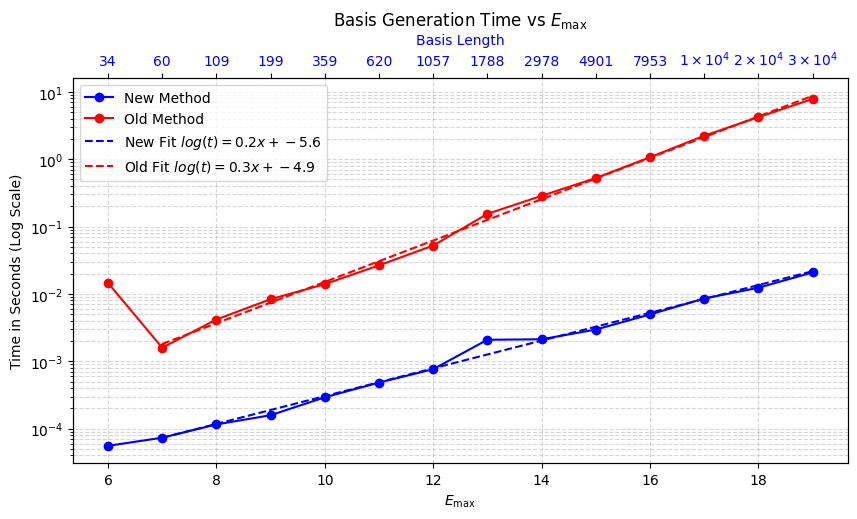

In [7]:
mQ = 1; r = 10/(2*math.pi)
execution_times = []; len_basis = []

emax_list = range(6,20) #Test Range of E_max.

# 1. Iterate over emax_list
for emax in emax_list:
    start_time = time.perf_counter()
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    # Generating the basis via the above method.
    basis = gen_basis(lmaxeff,emax,mQ,r)
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    execution_times.append(duration)
    len_basis.append(len(basis))
    
    del coins #For fairness, reset the coins dictionary each time.
    
    print(f"E_max: {emax} | Time: {duration:.6f} seconds")

# 2. Importing comparison timings. This file is produced from the old code and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_times_old = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    next(reader) #Skips Header.
    for row in reader:
        execution_times_old.append(float(row[1])) # Convert time back to float


# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds (Log Scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='New Method')
ax1.plot(emax_list, execution_times_old, marker ='o', linestyle='-', color='r', label='Old Method')

# 4. First degree polynomial fit to the timing data.
coef_new = (np.polyfit(emax_list[1:], np.log10(execution_times)[1:], 1))
coef_old = (np.polyfit(emax_list[1:], np.log10(execution_times_old)[1:], 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[1],emax_list[-1])

ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', label=f'New Fit $log(t)={coef_new[0]:.1f}x+{coef_new[1]:.1f}$')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', label=f'Old Fit $log(t)={coef_old[0]:.1f}x+{coef_old[1]:.1f}$')
ax1.legend()

# --- A second x-axis to show the basis length. 
ax2 = ax1.twiny() 
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(emax_list) 

formatted_top_labels = []
for x in len_basis:
    if x>10000:#Cleaning up long numbers into standard form.
        base, exponent = f"{x:.0e}".split("e")
        # Clean up the sign on the exponent (e.g., +06 becomes 6)
        exponent = int(exponent) 
        # Wrap in LaTeX math style for superscripts
        formatted_top_labels.append(f"${base} \\times 10^{{{exponent}}}$")
    else:
        formatted_top_labels.append(x)
    
ax2.set_xticklabels(formatted_top_labels) 
ax2.set_xlabel('Basis Length', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')


plt.title(r'Basis Generation Time vs $E_\text{max}$')
plt.show()


## 3. State Occupation Plot

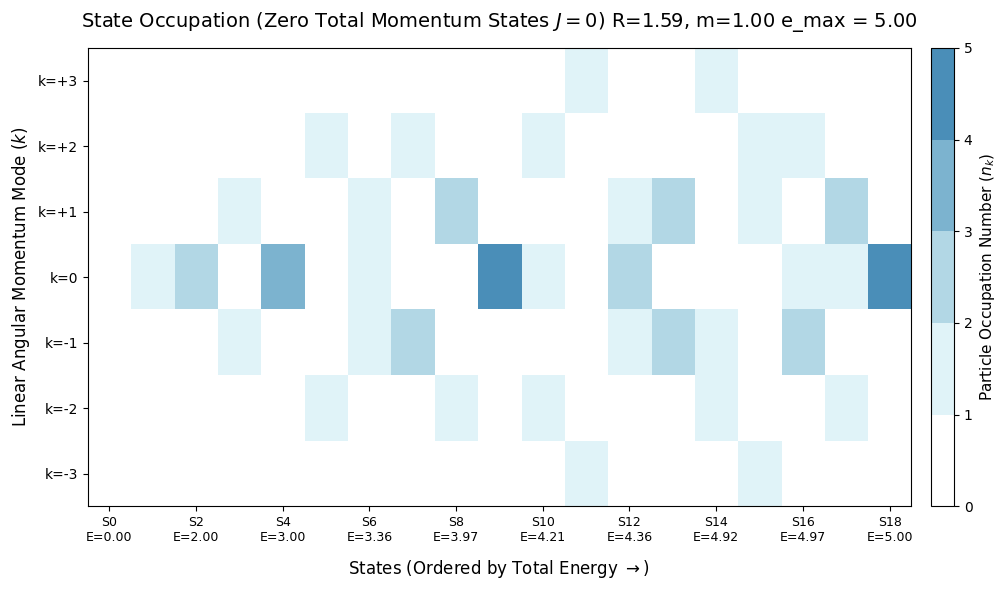

In [8]:
mQ = 1; r = 10/(2*math.pi); e_max=5; lmaxeff = effective_lmax(e_max,e_max,mQ,r)
basis = gen_basis(lmaxeff,e_max,mQ,r)

# -- Mode Range and J=0 Basis for Plot ---

lrange = lmaxeff
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))


# --- Sort states by energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []

# Computing the energies
state_energies = []
for state in _basis:
    state_energies.append(sum([nl*omega(l, mQ, r) for l, nl in state.items()]))

# Sorting the states
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Grid of Angular Momenta on the y-axis with States of Increasing Energies on x-axis ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes]
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]
    ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
    ax.set_xticklabels(_state_labels, fontsize=9)

else:
    ax.set_xticks(np.arange(0,len(sorted_states)))
    ax.set_xticklabels(state_labels, fontsize=9)

ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={mQ:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

## 4. Raising and lowering operations.
The following functions take two states, ordered in energy, and computes matrix element for their transition amplitude. The functions are classified by Hamming Distance.

- `phi2_hd0` — adds and removes one particle from the state.
- `phi2_hd2` — removes two particles with opposite angular momentum.


The correct symmetry factor is computed following arXiv:2507.15941 Eqs. (2.5)–(2.7).

In [9]:
def phi2_hd0(st):
    # --- One raising and one lowering operator applied to the same state.
    return 2*sum([st[l]/omega_list[abs(l)] for l in st.keys()])


def phi2_hd2(stA, stB):
    # --- Hamming distance 2 between states A and B. Must be energy ordered.
    for l in stA.keys():
        if (stA[l] - stB[l]) != 0:
            # Checks if it is simply reducing the l=0 state.
            if l==0:
                return math.sqrt(stA[0]*(stA[0]-1)) * (1/omega_list[0]) 
            
            if (stA[-l] - stB[-l]) != 0: 
                return 2*math.sqrt(stA[l]*stA[-l]) / (omega_list[abs(l)])
            
            else: return 0 


## 5. Transition Matrix by Hamming Distance 

Just considering `H_eff = H₀ + (m2)·H2`.

In [10]:
def basis_even(basis):  return [s for s in basis if sum(s.values()) % 2 == 0]
def basis_odd(basis):   return [s for s in basis if sum(s.values()) % 2 != 0]

In [ ]:
def transition_matrix(mV, sorted_basis, sorted_energies): 
    mV2=mV**2 

    # --- Hamming Distance Zero States ---

    H_eff = []
    
    H_eff += [((mV2/2) * phi2_hd0(state) + sorted_energies[ix]) for ix, state in enumerate(sorted_basis)]
    cols = [ix for ix in range(len(sorted_basis))]
    rows = [ix for ix in range(len(sorted_basis))]

    # --- Hamming Distance Two States


    # --- Alex's code for calculating the Hamming distance ---

    state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in sorted_basis])
    hamming_distances = np.sum(np.abs(state_vecs[np.newaxis,:,:] - state_vecs[:,np.newaxis,:]), axis=-1)


    # --- Now iterating over all zero or two Hamming Distance states. ---

    #Hamming Distance is Two:
    for ix, iy in zip(*np.where(hamming_distances==2)):
         if ix >= iy:

            res = (mV2/2) * phi2_hd2(sorted_basis[ix],sorted_basis[iy])
            H_eff.extend([res, res])
            rows.extend([ix, iy])
            cols.extend([iy, ix])


    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)

    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(sorted_basis),len(sorted_basis)))

In [85]:
# NOTE Input states and energies MUST first be sorted by occupation number, followed by energy.
def transition_matrix2(mV, sorted_basis, sorted_energies, boundaries, occupation_numbers): #Energy ordered basis needed.
    mV2=mV**2 

    # --- Now iterating over all zero or two Hamming Distance states. ---
    H_eff = []; cols = []; rows = []
    
    running_iy=Counter({0:0})
    for ix, state in enumerate(sorted_basis):
        if ix>0:
            #Hit the Diagonal.
            H_eff.extend([(mV2/2) * phi2_hd0(state) + sorted_energies[ix]])
            rows.extend([ix]); cols.extend([ix])
            
            for l in state.keys():
                if l==0 and state[l]>=2:
                    iy = max(boundaries[occupation_numbers[ix]-2],running_iy[l])
                    res = (mV2/2) * math.sqrt(state[0]*(state[0]-1)) * (1/omega_list[0]) 

                    H_eff.extend([res, res])
                    cols.extend([ix, iy]); rows.extend([iy, ix])
                    
                    running_iy[l] = iy + 1
                    
                elif l>0 and state[-l]!=0:
                    iy = max(boundaries[occupation_numbers[ix]-2],running_iy[l])
                    
                    res = mV2 * math.sqrt(state[l]*state[-l]) / (omega_list[abs(l)])

                    H_eff.extend([res, res])
                    cols.extend([ix, iy]); rows.extend([iy, ix])
                    
                    running_iy[l] = iy + 1
                    
            

    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)

    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(sorted_basis),len(sorted_basis)))

In [ ]:
# NOTE Input states and energies MUST first be sorted by occupation number, followed by energy.
def transition_matrix3(mV, sorted_basis, sorted_energies, boundaries): 
    mV2=mV**2 

    # --- Hamming Distance Zero States ---

    H_eff = []
    
    H_eff += [((mV2/2) * phi2_hd0(state) + sorted_energies[ix]) for ix, state in enumerate(sorted_basis)]
    cols = [ix for ix in range(len(sorted_basis))]
    rows = [ix for ix in range(len(sorted_basis))]

    # --- Hamming Distance Two States
    
    boundaries = np.insert(boundaries,0,-1)
    boundaries = np.append(boundaries, len(sorted_basis))

    #Iterating through the possible state occupation numbers, up to .
    for seg_ix in range(1,len(boundaries)-1):
        # --- Only supply states where the total occupation number differs by two. ---


        segment = sorted_basis[boundaries[seg_ix-1]+1:boundaries[seg_ix+1]+1]
        
        # --- Alex's code for calculating the Hamming distance. ---

        state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in segment])
        hamming_distances = np.sum(np.abs(state_vecs[np.newaxis,:,:] - state_vecs[:,np.newaxis,:]), axis=-1)


        # --- Now iterating over all zero or two Hamming Distance states. ---

        #Hamming Distance is Two:
        for ix, iy in zip(*np.where(hamming_distances==2)):
            if ix >= iy:

                res = (mV2/2) * phi2_hd2(segment[ix],segment[iy])
                H_eff += [res, res]
                rows += [ix+boundaries[seg_ix-1]+1, iy+boundaries[seg_ix-1]+1]
                cols += [iy+boundaries[seg_ix-1]+1, ix+boundaries[seg_ix-1]+1]


    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)

    return sp.coo_matrix((H_eff,(rows, cols)), shape=(len(sorted_basis),len(sorted_basis)))

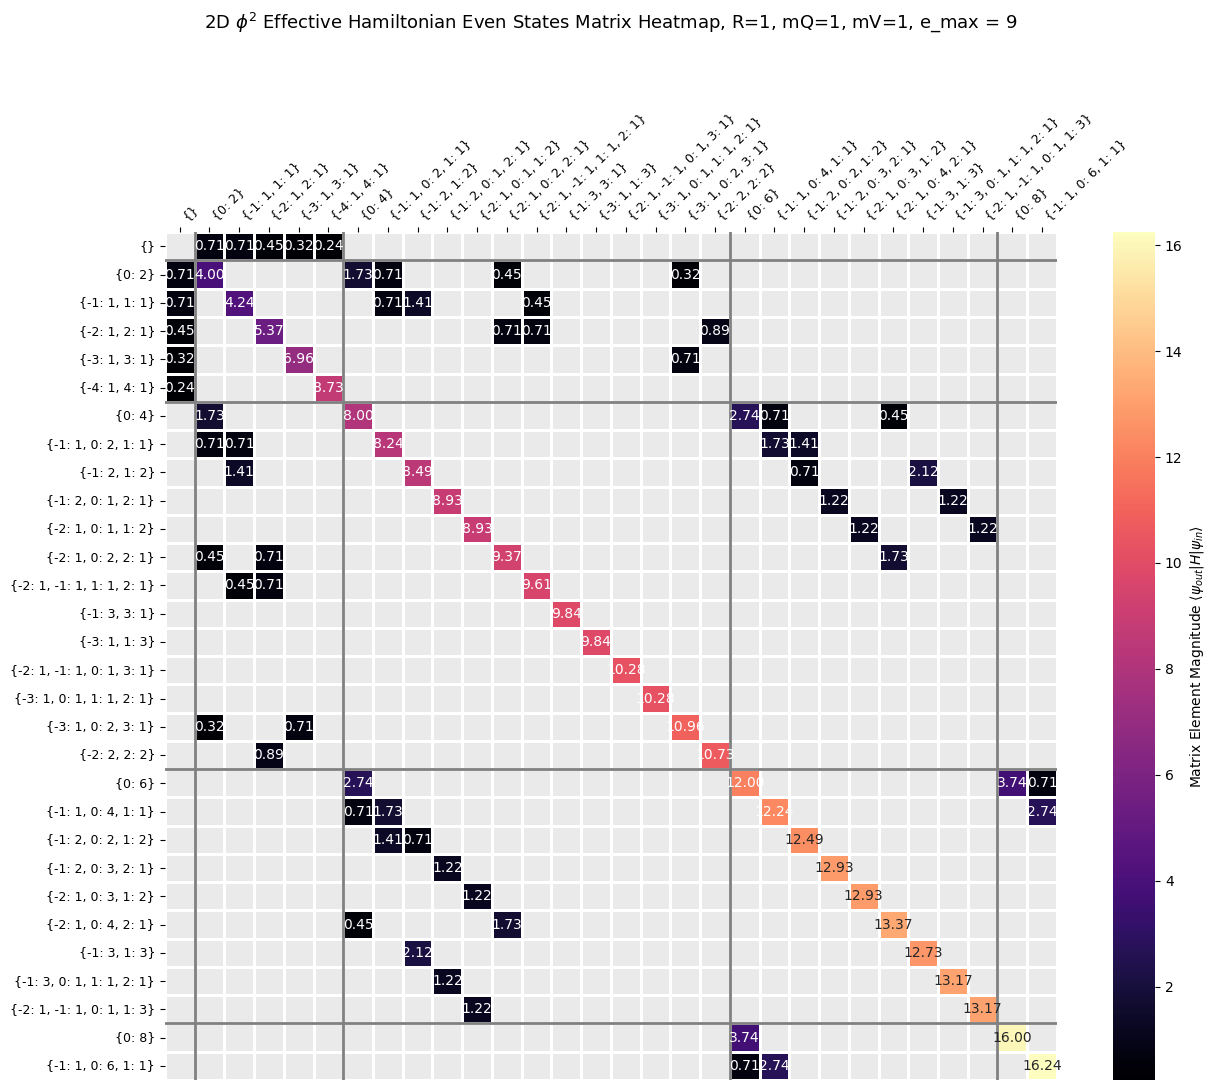

In [86]:
# --- Parameters for Test ---
mV = 1; mQ=1; r = 1; e_max=9; lmaxeff = effective_lmax(e_max,e_max,mQ,r)


basis = basis_even(gen_basis(lmaxeff,e_max,mQ,r)) #Select Even Basis States Only.
gen_omega_list(lmaxeff, mQ, r)


# 1. Compute properties.
occupation_numbers = np.array([get_total_occupation_number(state) for state in basis])
state_energies = np.array([get_state_energy(state, mQ, r) for state in basis])

# 2. Sort the basis using lexsort
sorted_indices = np.lexsort((state_energies, occupation_numbers))
sorted_basis = [basis[i] for i in sorted_indices]

# 3. Identify unique occupation values and their starting indices
# (Using the sorted array guarantees these indices mark the boundaries)
unique_occ, boundaries_vec = np.unique(occupation_numbers[sorted_indices], return_index=True)

# 4. Map the boundaries to a dictionary
boundaries = dict(zip(unique_occ, boundaries_vec))



H_eff_coo=transition_matrix2(mV, sorted_basis, state_energies[sorted_indices], boundaries, occupation_numbers[sorted_indices])


#sorted_indices = np.argsort(state_energies)
#sorted_basis = [basis[i] for i in sorted_indices]
#H_eff_coo=transition_matrix(mV, sorted_basis, state_energies[sorted_indices])


#%timeit transition_matrix3(mV, sorted_basis, state_energies[sorted_indices], boundaries)
#print('Original')
#%timeit transition_matrix(mV, sorted_basis, [get_state_energy(state, mQ, r) for state in sorted_basis])
#print('New Try')
#%timeit transition_matrix2(mV, sorted_basis, [get_state_energy(state, mQ, r) for state in sorted_basis])



# --- --- Plot --- ---

# --- Sorting the arrays nicely --- 

# Pre-calculate the sorting criteria for all states into NumPy arrays
occupation_numbers = np.array([get_total_occupation_number(state) for state in sorted_basis])
energies = np.array([get_state_energy(state, mQ, r) for state in sorted_basis])

# Pass them to lexsort: (secondary_key, primary_key)
sorted_indices = np.lexsort((energies, occupation_numbers))

# Sorting states and the H_eff matrix.
sorted_states = [sorted_basis[i] for i in sorted_indices]
sorted_H_eff = H_eff_coo.toarray()[sorted_indices, :][:, sorted_indices]



# --- State labels ---
verbose_labels = []
for state in sorted_states:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}")

# --- Boundaries between occupation numbers ---
state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in sorted_states])
boundaries = np.where(np.diff(np.sort(np.sum(state_vecs, axis=1))))[0]
boundaries[0] = 0

# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(13, 11))

zero_mask = (sorted_H_eff == 0.0)
ax = sns.heatmap(
    sorted_H_eff, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)

for b in boundaries:
    ax.axvline(x=b+1, linewidth=2, color="grey")
    ax.axhline(y=b+1, linewidth=2, color="grey")


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title(rf"2D $\phi^2$ Effective Hamiltonian Even States Matrix Heatmap, R={r}, mQ={mQ}, mV={mV}, e_max = {e_max}", fontsize=13, pad=60)
plt.tight_layout()
plt.show()


## Timing Code to Compare with https://arxiv.org/abs/2110.08273

----- Hamming Distance Timing -----
E_max: 6 | Time: 0.000337 seconds
E_max: 7 | Time: 0.000330 seconds
E_max: 8 | Time: 0.001146 seconds
E_max: 9 | Time: 0.001157 seconds
E_max: 10 | Time: 0.000551 seconds
E_max: 11 | Time: 0.000886 seconds
E_max: 12 | Time: 0.001172 seconds
E_max: 13 | Time: 0.003105 seconds
E_max: 14 | Time: 0.003811 seconds
E_max: 15 | Time: 0.007168 seconds
E_max: 16 | Time: 0.011152 seconds
E_max: 17 | Time: 0.019420 seconds
E_max: 18 | Time: 0.032893 seconds
E_max: 19 | Time: 0.101026 seconds
E_max: 20 | Time: 0.246095 seconds
E_max: 21 | Time: 0.926621 seconds
E_max: 22 | Time: 1.888889 seconds
E_max: 23 | Time: 3.229589 seconds
E_max: 24 | Time: 6.483951 seconds
----- Alternative Method Timing -----
E_max: 6 | Time: 0.000655 seconds
E_max: 7 | Time: 0.000077 seconds
E_max: 8 | Time: 0.000081 seconds
E_max: 9 | Time: 0.000090 seconds
E_max: 10 | Time: 0.000112 seconds
E_max: 11 | Time: 0.000610 seconds
E_max: 12 | Time: 0.000194 seconds
E_max: 13 | Time: 0.0003

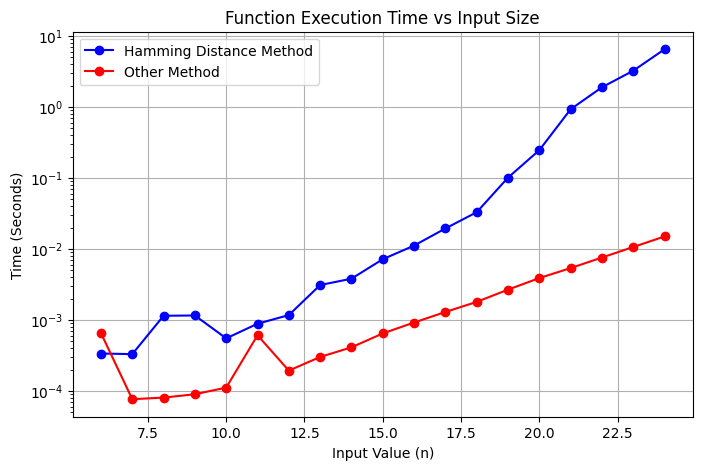

In [87]:
m = 1; r = 1
execution_times = []; execution_times2 = []; basis_lengths = []

emax_list = range(6,25)

print('----- Hamming Distance Timing -----')
for emax in emax_list:
    

    lmaxeff = effective_lmax(emax,emax,m,r)
    basis = basis_even(gen_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)

    start_time = time.perf_counter()
    
    energies = [get_state_energy(state, mQ, r) for state in sorted_basis]

    sorted_basis = sorted(basis, key=lambda state: (get_state_energy(state,mQ,r))) #Sort basis by energy.
    
    # --- Run the transition matrix generation.
    transition_matrix(mV, sorted_basis, [get_state_energy(state, mQ, r) for state in sorted_basis])

    
    end_time = time.perf_counter()
    duration = end_time - start_time
    execution_times.append(duration)
    basis_lengths.append(len(basis))
    
    print(f"E_max: {emax} | Time: {duration:.6f} seconds")
    

print('----- Alternative Method Timing -----')

for emax in emax_list:
    

    lmaxeff = effective_lmax(emax,emax,m,r)
    basis = basis_even(gen_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)
    start_time = time.perf_counter()

    # 1. Compute properties using vectorization if possible
    occupation_numbers = np.array([get_total_occupation_number(state) for state in basis])
    state_energies = np.array([get_state_energy(state, mQ, r) for state in basis])

    # 2. Sort the basis using lexsort
    sorted_indices = np.lexsort((state_energies, occupation_numbers))
    sorted_basis = [basis[i] for i in sorted_indices]

    # 3. Identify unique occupation values and their starting indices
    # (Using the sorted array guarantees these indices mark the boundaries)
    unique_occ, boundaries_vec = np.unique(occupation_numbers[sorted_indices], return_index=True)

    # 4. Map the boundaries to a dictionary
    boundaries = dict(zip(unique_occ, boundaries_vec))
    
    # --- Run the transition matrix generation.

    transition_matrix2(mV, sorted_basis, state_energies[sorted_indices], boundaries, occupation_numbers[sorted_indices])


    end_time = time.perf_counter()
    duration = end_time - start_time
    execution_times2.append(duration)
    basis_lengths.append(len(basis))
    
    print(f"E_max: {emax} | Time: {duration:.6f} seconds")


# 3. Export results to a CSV file
csv_filename = "improved_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times2))

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label="Hamming Distance Method")

plt.plot(emax_list, execution_times2, marker='o', linestyle='-', color='r', label="Other Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Diagonalization

For small matrices we use dense `eigvalsh`. For large ones we use a sparse shift-invert trick to find the `k` lowest eigenvalues without forming the dense matrix.

In [16]:
def compute_eigenvalues(H, k):
    """Return the k lowest eigenvalues of sparse symmetric H."""
    n = H.shape[0]
    k = min(k, n)
    if k > n - 2:
        return sorted(np.linalg.eigvalsh(H.toarray()))[:k]
    # Shift by the matrix norm so eigs(..., which='LM') finds the most-negative eigenvalues of H
    norm = sp_linalg.norm(H)
    eigs = sp_linalg.eigs(H - norm*identity(n), k, which='LM')[0]
    return sorted((eigs.real + norm).tolist())
